# Evaluate Other Classifiers (COUGHVID)

比較 Naive Bayes、SVM、Random Forest 在 COUGHVID 三分類任務上的表現。

Train：專家標註（已 balanced）
Test：`status_SSL`（真實分布）

## Imports

In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import KFold
from utils import plot_confusion_matrix

## Hyperparameters

In [2]:
hparams = {
    'train_dataset': 'data/prepared_train_coughvid_balanced.csv',
    'test_dataset':  'data/prepared_test_split.csv',
    'features': [
        'chroma_stft', 'rmse', 'spectral_centroid', 'spectral_bandwidth', 'rolloff', 'zero_crossing_rate',
        'mfcc1', 'mfcc2', 'mfcc3', 'mfcc4', 'mfcc5', 'mfcc6', 'mfcc7', 'mfcc8', 'mfcc9', 'mfcc10',
        'mfcc11', 'mfcc12', 'mfcc13', 'mfcc14', 'mfcc15', 'mfcc16', 'mfcc17', 'mfcc18', 'mfcc19', 'mfcc20'
    ]
}

## Prepare Data

In [3]:
# --- Train ---
df_train = pd.read_csv(hparams['train_dataset'])
X_train  = np.array(df_train[hparams['features']], dtype=np.float32)

encoder = LabelEncoder()
y_train = encoder.fit_transform(df_train['label'])
print('classes:', encoder.classes_)
print('Train label 分佈:')
print(df_train['label'].value_counts())

# --- Test ---
df_test = pd.read_csv(hparams['test_dataset'])
X_test  = np.array(df_test[hparams['features']], dtype=np.float32)
y_test  = encoder.transform(df_test['label'])
print('\nTest label 分佈:')
print(df_test['label'].value_counts())

# --- Scale ---
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

X = np.concatenate([X_train, X_test])
y = np.concatenate([y_train, y_test])

classes: ['covid' 'healthy' 'symptomatic']
Train label 分佈:
label
covid          470
healthy        470
symptomatic    470
Name: count, dtype: int64

Test label 分佈:
label
symptomatic    94
covid          94
healthy        94
Name: count, dtype: int64


In [4]:
def train_eval_classifier(clf):
    clf.fit(X_train, y_train)

    predictions = clf.predict(X_train)
    accuracy_train = np.sum(predictions == y_train) / len(y_train)
    print('Train Accuracy:', accuracy_train)

    predictions = clf.predict(X_test)
    accuracy_test = np.sum(predictions == y_test) / len(y_test)
    print('Test Accuracy:', accuracy_test)

    plot_confusion_matrix(y_test, predictions, encoder.classes_)

def k_fold_train_eval_classifier(clf):
    k_folds = 4
    kfold   = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    indices = np.arange(len(y))

    results_train = []
    results_test  = []

    print(f'K-FOLD CROSS VALIDATION RESULTS FOR {k_folds} FOLDS')
    print('--------------------------------------------')
    print('|         | Train Accuracy | Test Accuracy |')
    print('--------------------------------------------')

    for fold, (train_ids, test_ids) in enumerate(kfold.split(indices)):
        X_tr, X_te = X[train_ids], X[test_ids]
        y_tr, y_te = y[train_ids], y[test_ids]

        clf.fit(X_tr, y_tr)

        train_accuracy = np.sum(clf.predict(X_tr) == y_tr) / len(y_tr)
        eval_accuracy  = np.sum(clf.predict(X_te) == y_te) / len(y_te)
        results_train.append(train_accuracy)
        results_test.append(eval_accuracy)

        print(f'| Fold {fold}  |       {train_accuracy*100:.2f} % |       {eval_accuracy*100:.2f} % |')

    print('--------------------------------------------')
    print(f'| Average |       {np.mean(results_train)*100:.2f} % |       {np.mean(results_test)*100:.2f} % |')

    predictions = clf.predict(X_te)
    plot_confusion_matrix(y_te, predictions, encoder.classes_)

## Naive Bayes

K-FOLD CROSS VALIDATION RESULTS FOR 4 FOLDS
--------------------------------------------
|         | Train Accuracy | Test Accuracy |
--------------------------------------------
| Fold 0  |       44.52 % |       40.66 % |
| Fold 1  |       42.32 % |       42.08 % |
| Fold 2  |       45.00 % |       36.64 % |
| Fold 3  |       42.32 % |       39.48 % |
--------------------------------------------
| Average |       43.54 % |       39.72 % |


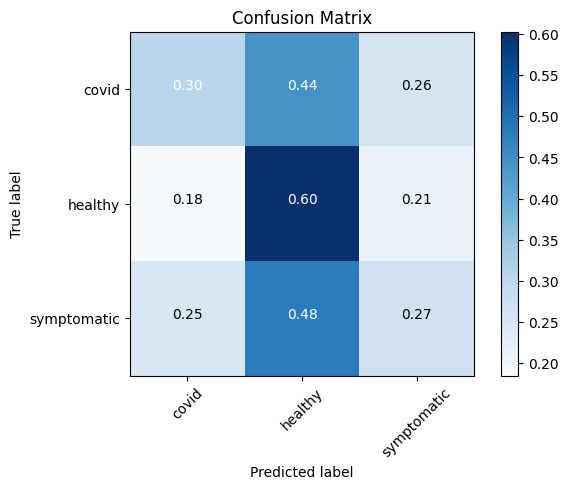

In [5]:
from sklearn.naive_bayes import GaussianNB
clf = GaussianNB()
k_fold_train_eval_classifier(clf)

## Support Vector Machine

K-FOLD CROSS VALIDATION RESULTS FOR 4 FOLDS
--------------------------------------------
|         | Train Accuracy | Test Accuracy |
--------------------------------------------
| Fold 0  |       70.61 % |       47.28 % |
| Fold 1  |       74.31 % |       48.46 % |
| Fold 2  |       69.03 % |       41.37 % |
| Fold 3  |       72.81 % |       48.70 % |
--------------------------------------------
| Average |       71.69 % |       46.45 % |


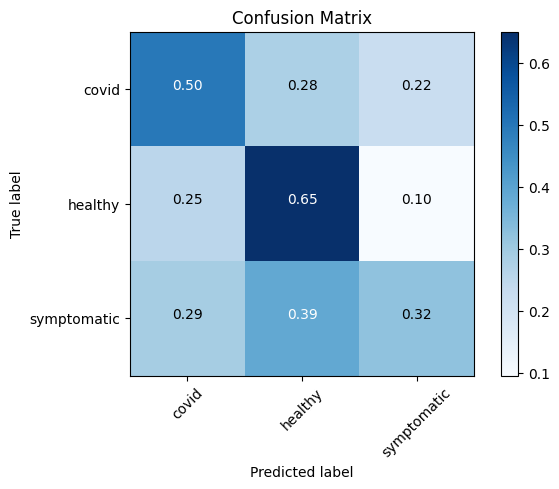

In [6]:
from sklearn import svm
clf = svm.SVC(kernel='poly')
k_fold_train_eval_classifier(clf)

## Random Forest

K-FOLD CROSS VALIDATION RESULTS FOR 4 FOLDS
--------------------------------------------
|         | Train Accuracy | Test Accuracy |
--------------------------------------------
| Fold 0  |       99.37 % |       56.97 % |
| Fold 1  |       99.53 % |       55.79 % |
| Fold 2  |       99.29 % |       52.48 % |
| Fold 3  |       99.76 % |       56.97 % |
--------------------------------------------
| Average |       99.49 % |       55.56 % |


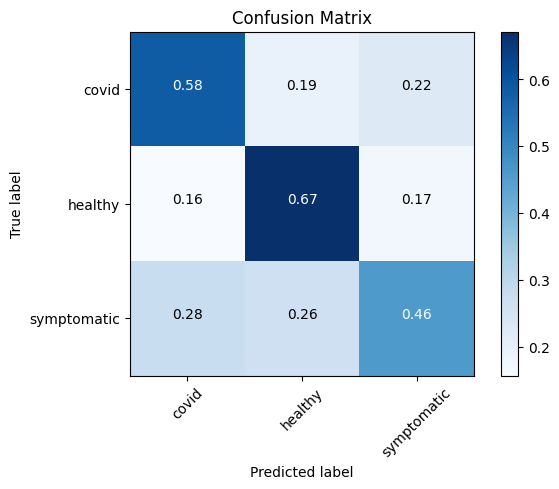

In [7]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(max_depth=10, n_estimators=100, random_state=42)
k_fold_train_eval_classifier(clf)